In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
np.random.seed(42)
tf.random.set_seed(42)


# ── 2. LOAD DATA ─────────────────────────────────────────────
df = pd.read_csv("D:\\ann_01\\Artificial_Neural_Network_Case_Study_data.csv")

print("Shape:", df.shape)
print(df.head())
print("\nChurn Rate: {:.2f}%".format(df['Exited'].mean() * 100))

Shape: (10000, 14)
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63     

In [3]:
# ── 3. PREPROCESSING ─────────────────────────────────────────
# Drop irrelevant columns
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

# Encode Gender
df['Gender'] = LabelEncoder().fit_transform(df['Gender'])  # Female=0, Male=1

# One-Hot Encode Geography
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# Features & Target
X = df.drop('Exited', axis=1)
feature_columns = X.columns.tolist()
y = df['Exited'].values

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("\nX_train:", X_train.shape, "| X_test:", X_test.shape)


X_train: (8000, 11) | X_test: (2000, 11)


In [4]:
# ── 4. BUILD ANN ─────────────────────────────────────────────
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

d:\ann_01\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 192 (768.00 B)

In [5]:
# ── 5. TRAIN ──────────────────────────────────────────────────
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    class_weight={0: 1, 1: 2},   # handle class imbalance
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6794 - loss: 0.7953 - val_accuracy: 0.7994 - val_loss: 0.4982
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7684 - loss: 0.6793 - val_accuracy: 0.8150 - val_loss: 0.4391
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7845 - loss: 0.6349 - val_accuracy: 0.8256 - val_loss: 0.4152
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8003 - loss: 0.6176 - val_accuracy: 0.8263 - val_loss: 0.4019
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8028 - loss: 0.6012 - val_accuracy: 0.8219 - val_loss: 0.3969
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8097 - loss: 0.5927 - val_accuracy: 0.8256 - val_loss: 0.3897
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8128 - loss: 0.5857 - val_accuracy: 0.8263 - val_loss: 0.3861
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8116 - loss: 0.5741 - val_accu

In [6]:

# ── 6. EVALUATE ───────────────────────────────────────────────
y_pred  = (model.predict(X_test) >= 0.5).astype(int).ravel()
y_prob  = model.predict(X_test).ravel()

_, acc  = model.evaluate(X_test, y_test, verbose=0)
auc     = roc_auc_score(y_test, y_prob)

print(f"\nTest Accuracy : {acc*100:.2f}%")
print(f"Test AUC-ROC  : {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Test Accuracy : 84.00%
Test AUC-ROC  : 0.8532

Classification Report:
              precision    recall  f1-score   support

    Retained       0.90      0.89      0.90      1593
     Churned       0.60      0.63      0.62       407

    accuracy                           0.84      2000
   macro avg       0.75      0.76      0.76      2000
weighted avg       0.84      0.84      0.84      2000



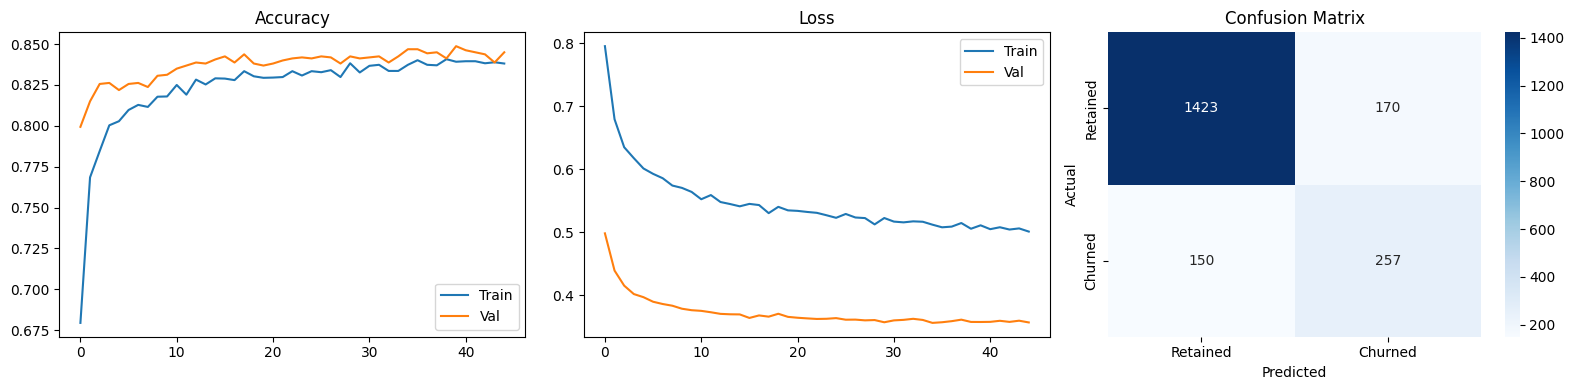

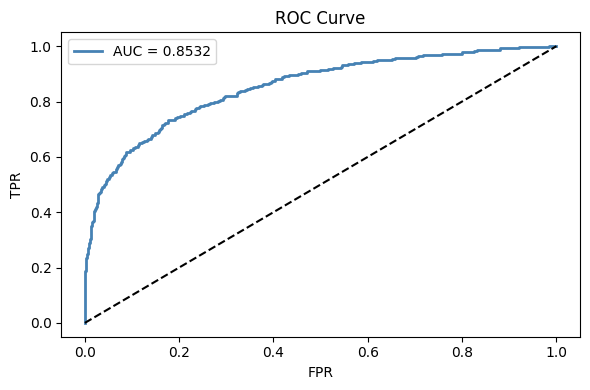

In [7]:
# ── 7. PLOTS ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Training curves
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy'); axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss'); axes[1].legend()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('results.png', dpi=150)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}', color='steelblue', lw=2)
plt.plot([0,1],[0,1],'k--')
plt.title('ROC Curve'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.legend(); plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

In [ ]:
# ── 8. PREDICT NEW CUSTOMER ───────────────────────────────────
# Example: CreditScore, Gender(0=F,1=M), Age, Tenure, Balance,
#          NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary,
#          Geography_Germany, Geography_Spain
new_customer = scaler.transform([[600, 1, 40, 3, 60000, 2, 1, 1, 80000, 0, 0]])
prob = model.predict(new_customer)[0][0]
stay_prob = 1 - prob
print(f"\nNew Customer Churn Probability: {prob*100:.2f}%")
print(f"New Customer Stay Probability: {stay_prob*100:.2f}%")
print("Prediction:", "WILL CHURN" if prob >= 0.5 else "WILL STAY")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

New Customer Churn Probability: 7.48%
Prediction: WILL STAY


In [9]:
from pathlib import Path
import json
import pickle

# ── 9. SAVE ARTIFACTS ─────────────────────────────────────────
artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(exist_ok=True)

model.save(artifacts_dir / 'churn_ann_model.keras')

with open(artifacts_dir / 'scaler.pkl', 'wb') as file_handle:
    pickle.dump(scaler, file_handle)

with open(artifacts_dir / 'feature_columns.json', 'w', encoding='utf-8') as file_handle:
    json.dump(feature_columns, file_handle, indent=2)

print('Saved model to artifacts/churn_ann_model.keras')
print('Saved scaler to artifacts/scaler.pkl')
print('Saved feature columns to artifacts/feature_columns.json')

Saved model to artifacts/churn_ann_model.keras
Saved scaler to artifacts/scaler.pkl
Saved feature columns to artifacts/feature_columns.json
